# The Data Pipeline

The earlier phases hand-built their input tensors. This notebook runs the **real pipeline** end to end on the iris dataset, then points the project's visualization tools at the resulting run. The flow has four stages, each a separate responsibility:

`CSVDataset`  →  `split_train_val_test`  →  `DataLoader`  →  model

- **`Dataset`** turns files on disk into individual samples.
- **`split_train_val_test`** partitions the samples and *fits* the label encoding on the training data only.
- **`DataLoader`** collates samples into batched tensors on the fly — one minibatch at a time.
- the **model** never sees the pipeline; it only consumes `(features, target)` tensors.

We train a small classifier, **visualize** the run (loss curves, weight/gradient distributions, and the network graph), and evaluate on the held-out test split.

In [1]:
from pathlib import Path
from random import seed
from statistics import mean

from babygrad.data import CSVDataset, DataLoader, split_train_val_test
from babygrad.metrics import Accuracy
from babygrad.nn.activations import ReLU, Softmax
from babygrad.nn.losses import CCE
from babygrad.nn.model import Model
from babygrad.nn.modules import Linear, Sequential
from babygrad.nn.optimizers import SGD
from babygrad.recorder import Recorder
from babygrad.viz.graph import GraphVisualizer
from babygrad.viz.plot import PlotVisualizer

seed(0)  # deterministic split + minibatch shuffling

# run from the notebooks/ dir (Jupyter default) or the repo root
DATA = Path("../data/iris.csv")
if not DATA.exists():
    DATA = Path("data/iris.csv")

## 1. Dataset: storage → samples

`CSVDataset` reads the whole iris file into memory once (eager loading — fine for a small tabular file) and exposes it as a sequence of `Sample`s. Indexing returns one model-bound row: the features already split from the target, as a named pair rather than anonymous columns.

In [2]:
dataset = CSVDataset(DATA, target_col_idx=4)
print(f"{len(dataset)} samples")
dataset[0]

150 samples


Sample(features=[5.1, 3.5, 1.4, 0.2], target=['Iris-setosa'])

## 2. Split: partition + fit-on-train encoding

`split_train_val_test` shuffles and slices the samples into the three splits. With `one_hot=True` it also **fits** a label→one-hot mapping *on the training split only* and shares that same mapping to val/test — so the encoding can never leak unseen-label information, and the encoded width is known up front.

`n_features` / `n_targets` read straight off the split (the latter from the fitted mapping), so the model can be sized from them.

In [3]:
train, val, test = split_train_val_test(dataset, one_hot=True)

print(f"sizes      train={len(train)}  val={len(val)}  test={len(test)}")
print(f"n_features {train.n_features}   n_targets {train.n_targets}")
print(f"one-hot    {train.one_hot_mapping}")

sizes      train=120  val=15  test=15
n_features 4   n_targets 3
one-hot    {'Iris-versicolor': [1, 0, 0], 'Iris-virginica': [0, 1, 0], 'Iris-setosa': [0, 0, 1]}


## 3. DataLoader: samples → batched tensors

The `DataLoader` wraps a split and, on iteration, shuffles it and yields `Batch`es. Each `Batch` is built **on the fly**: raw `Sample` rows are collated into one `(batch, n_features)` features tensor and one `(batch, n_targets)` target tensor — the labels one-hot encoded via the shared mapping. Nothing is tensorized until the batch is requested.

For validation/test we want the *whole* split as a single batch; `full_batch()` is exactly `next(iter(loader))` with the batch size defaulting to the full split.

In [4]:
one_batch = next(iter(DataLoader(train, batch_size=16)))
print("minibatch  features", one_batch.features.shape, " target", one_batch.target.shape)

val_x, val_y = DataLoader(val).full_batch()
print("full batch features", val_x.shape, " target", val_y.shape)

minibatch  features (16, 4)  target (16, 3)
full batch features (15, 4)  target (15, 3)


## 4. Model: sized from the split

A plain MLP. Note the first and last layers are sized directly from `train.n_features` and `train.n_targets` — the pipeline tells the model its input and output shapes, so nothing is hard-coded.

In [5]:
net = Sequential([
    Linear(train.n_features, 32),
    ReLU(),
    Linear(32, train.n_targets),
    Softmax(),
])
model = Model(net)
optimizer = SGD(net.parameters())
optimizer.lr = 0.1
criterion = CCE()

## 5. Training loop

Each epoch builds a fresh `DataLoader` (re-shuffling the minibatches), and validation runs once per epoch on the full val batch. A `Recorder` snapshots the scalar metrics each step and `capture()`s the parameter/gradient distributions from the graph — that history is what the visualizers read in the next section. The loop itself only ever touches `(x, y)` tensors; it has no idea they came from a CSV.

In [6]:
epochs, batch_size = 120, 16
recorder = Recorder()

for epoch in range(epochs):
    recorder.step = epoch
    batch_losses = []
    for x, y in DataLoader(train, batch_size):
        optimizer.zero_grad()
        loss = criterion.forward(y, model.forward(x))
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.data[0])

    val_pred = model.eval(val_x)
    recorder.capture(root=loss)  # harvest weights/grads from the last batch's graph
    recorder.record("train_loss", mean(batch_losses))
    recorder.record("val_loss", criterion.forward(val_y, val_pred).data[0])
    recorder.record("val_acc", Accuracy().compute(val_y, val_pred))

print(f"final  train_loss {recorder.history['train_loss'][epochs - 1]:.4f}"
      f"  val_loss {recorder.history['val_loss'][epochs - 1]:.4f}"
      f"  val_acc {recorder.history['val_acc'][epochs - 1]:.3f}")

final  train_loss 0.0881  val_loss 0.0481  val_acc 1.000


## 6. Visualizing the run

Because that was a *real* training run, every tool from the visualization phase reads straight from it. `PlotVisualizer` consumes the `Recorder`'s history; `GraphVisualizer` walks the autograd graph of a single loss tensor. Same model, three different lenses.

### Loss and accuracy over time

Scalar series from the recorder — the training/validation loss and the validation accuracy, one point per epoch.

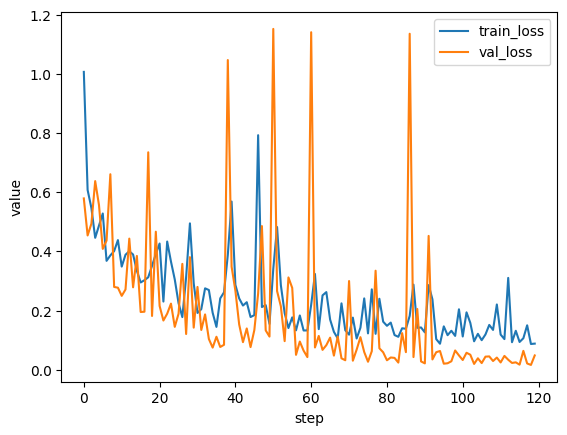

In [7]:
viz = PlotVisualizer(recorder.history)
viz.plot_scalar(["train_loss", "val_loss"])

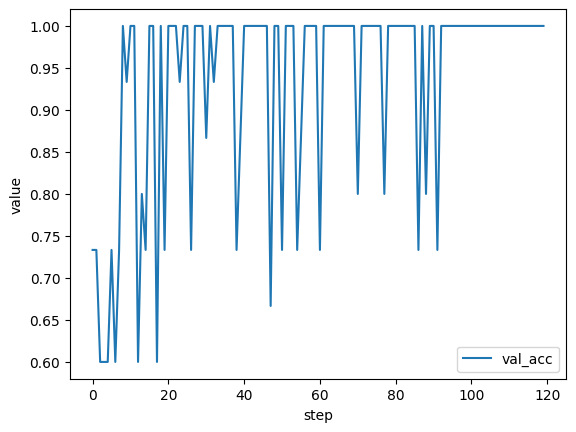

In [8]:
viz.plot_scalar(["val_acc"])

### Weight and gradient distributions

A *ridge* plot stacks one histogram per epoch (earliest at the bottom), so you can watch a distribution drift as training proceeds — the first layer's weights spreading out, and its gradients (heavy-tailed, so clipped to the 1st–99th percentile).

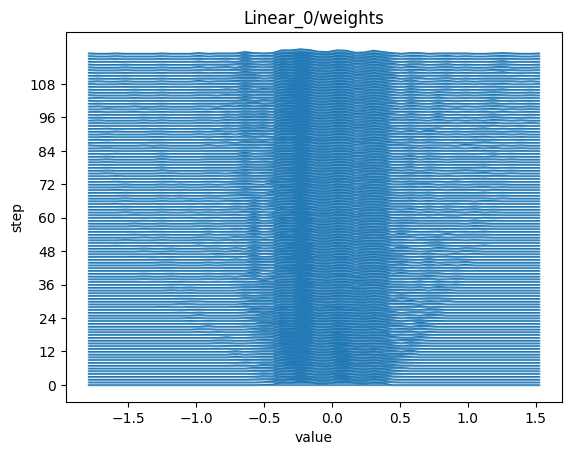

In [9]:
viz.plot_ridge("Linear_0/weights")

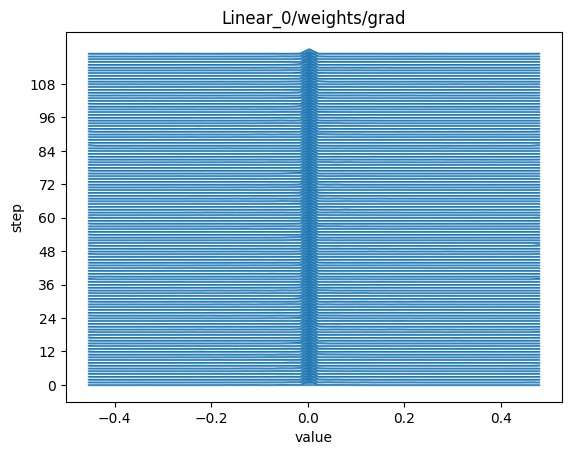

In [10]:
viz.plot_ridge("Linear_0/weights/grad", clip_quantiles=(0.01, 0.99))

### The network as a graph

`GraphVisualizer` walks the autograd graph backward from a single loss tensor. Three levels of zoom on the *same* forward/backward pass over the piped data:

- **computation** — every op as its own node,
- **combined** — the same graph with each layer's nodes boxed into its scope,
- **architecture** — each layer collapsed to one box, edges labelled with the tensor shape crossing between them.

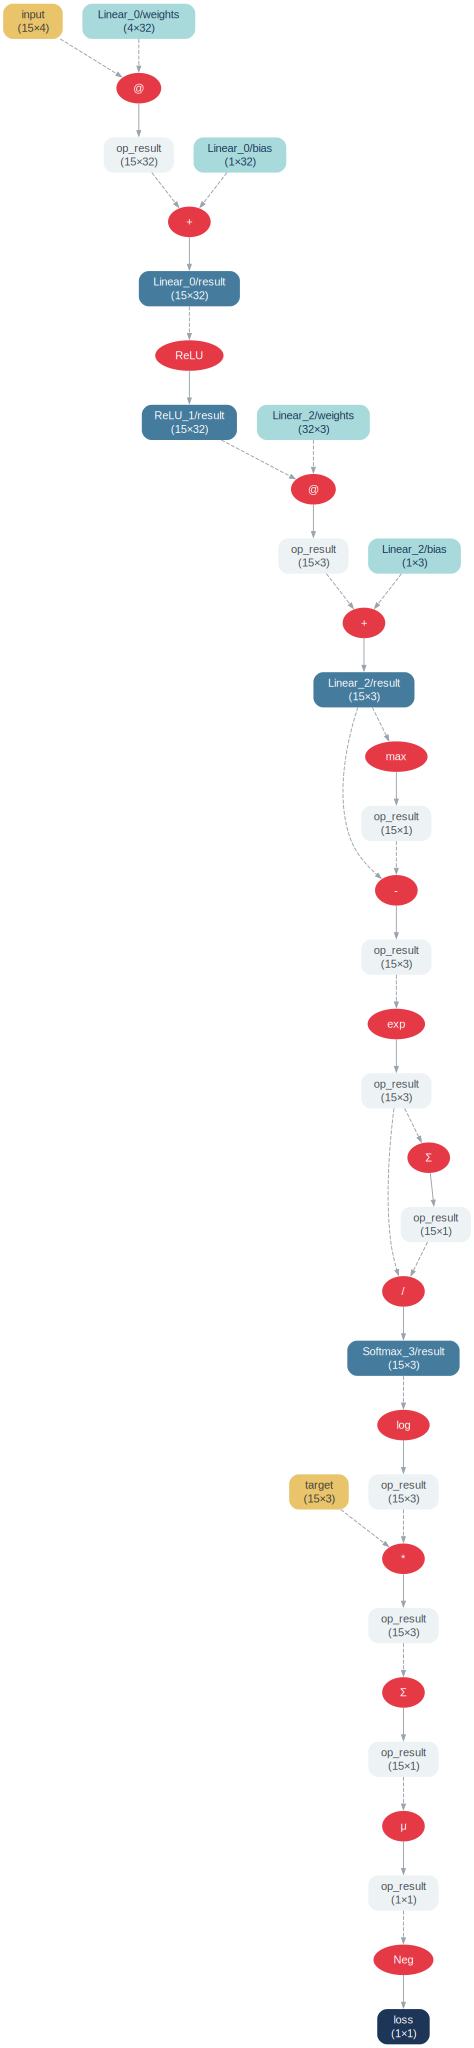

In [11]:
graph = GraphVisualizer(criterion.forward(val_y, model.forward(val_x)))
graph.draw_computation()

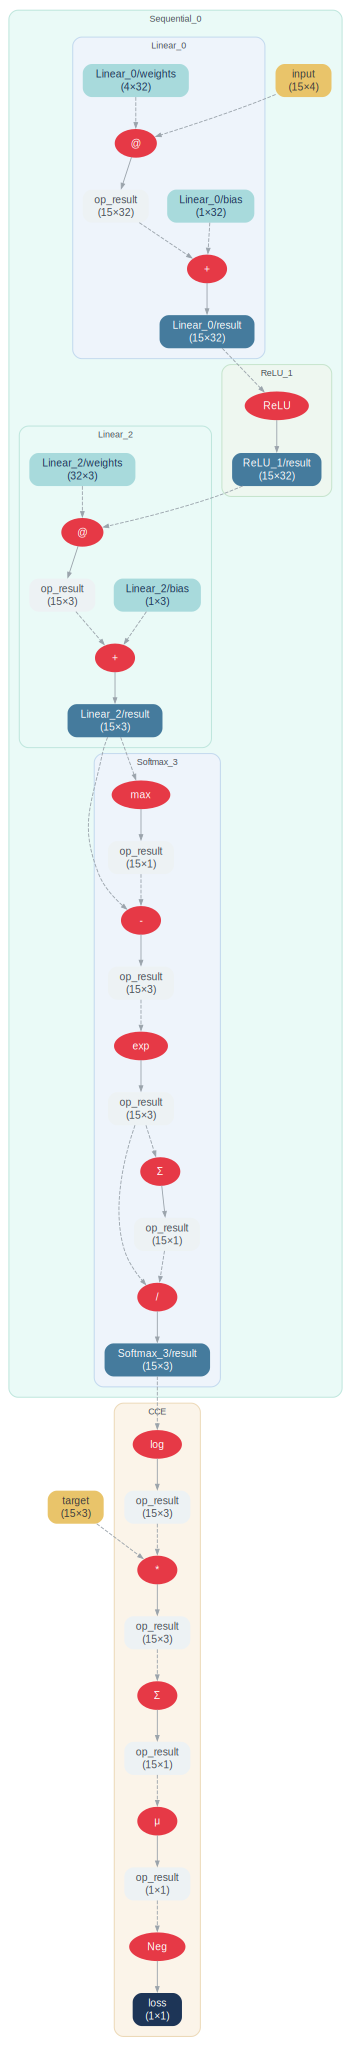

In [12]:
graph.draw_combined()

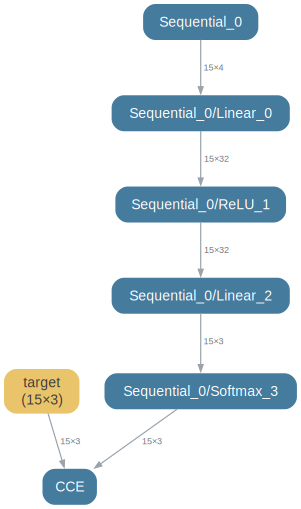

In [13]:
graph.draw_architecture()

## 7. Evaluation

Finally, the held-out test split — loaded through the same pipeline, evaluated in one `full_batch()` pass.

In [14]:
test_x, test_y = DataLoader(test).full_batch()
test_pred = model.eval(test_x)
print(f"test loss {criterion.forward(test_y, test_pred).data[0]:.4f}"
      f"   test acc {Accuracy().compute(test_y, test_pred):.3f}")

test loss 0.1281   test acc 0.933


## Recap

Four responsibilities, cleanly separated:

| stage | input | output |
|---|---|---|
| `CSVDataset` | a CSV file | `Sample(features, target)` rows |
| `split_train_val_test` | a dataset | three splits + a fit-on-train encoder |
| `DataLoader` | a split | batched `(features, target)` tensors, on demand |
| model / loss | tensors | predictions, gradients |

The model and training loop are completely blind to where the data came from — they only ever see tensors, which is what let the visualizers plug straight in. That same blindness is what will let the *same* loop train on a different dataset later: only the `Dataset` changes. The one piece that will need to grow is the `DataLoader`'s collate step, when sequence data (transformers) forces padding + masking — but for tabular data, this is the whole pipeline.